In [1]:
#Import dependencies
from afmlevel.background_model import level_ml_bg
from afmlevel.mask_model import level_ml_mask, ml_mask
import os
import numpy as np
from PIL import Image
from sklearn.metrics import mean_squared_error
from skimage.metrics import peak_signal_noise_ratio
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
import torch

# Load AFM colourmap
AFM = np.load('./lutAFM.npy') # by default the working directory is the folder the notebook is in, i.e. /notebooks
AFM = ListedColormap(AFM)

# Load demo images
image_path = r"C:\Users\pymte\OneDrive - University of Leeds\George Heath's files - Annexin assembly\imaging-13.47.52.797"  
images = []
for file in os.listdir(image_path):
    images.append(file)

# Load models
bg_model_path = r"C:\Users\pymte\OneDrive - University of Leeds\Project 2\Machine Learning\afMLevel files\BGModel.pth"
mask_model_path = r"C:\Users\pymte\OneDrive - University of Leeds\Project 2\Machine Learning\afMLevel files\MaskModel.pth"

In [2]:
from playnano import afm_stack

stack = afm_stack.AFMImageStack.load_data(image_path, channel="height_retrace")
stack_bg = afm_stack.AFMImageStack.load_data(image_path, channel="height_retrace")

16:28:04 | INFO |jpk.py:jpk:load_jpk:213 | Loading image from : C:\Users\pymte\OneDrive - University of Leeds\George Heath's files - Annexin assembly\imaging-13.47.52.797\save-2022.11.04-13.47.52.829.jpk
16:28:04 | INFO |jpk.py:jpk:_load_jpk_tags:274 | Configuration loaded from : C:\Users\pymte\AppData\Local\anaconda3\envs\afmlevelenv\Lib\site-packages\AFMReader\default_config.yaml
16:28:04 | INFO |jpk.py:jpk:load_jpk:251 | [save-2022.11.04-13.47.52.829] : Extracted image.
16:28:04 | INFO |jpk.py:jpk:load_jpk:213 | Loading image from : C:\Users\pymte\OneDrive - University of Leeds\George Heath's files - Annexin assembly\imaging-13.47.52.797\save-2022.11.04-13.47.52.829.jpk
16:28:04 | INFO |jpk.py:jpk:_load_jpk_tags:274 | Configuration loaded from : C:\Users\pymte\AppData\Local\anaconda3\envs\afmlevelenv\Lib\site-packages\AFMReader\default_config.yaml
16:28:04 | INFO |jpk.py:jpk:load_jpk:251 | [save-2022.11.04-13.47.52.829] : Extracted image.
16:28:04 | INFO |jpk.py:jpk:load_jpk:213 | L

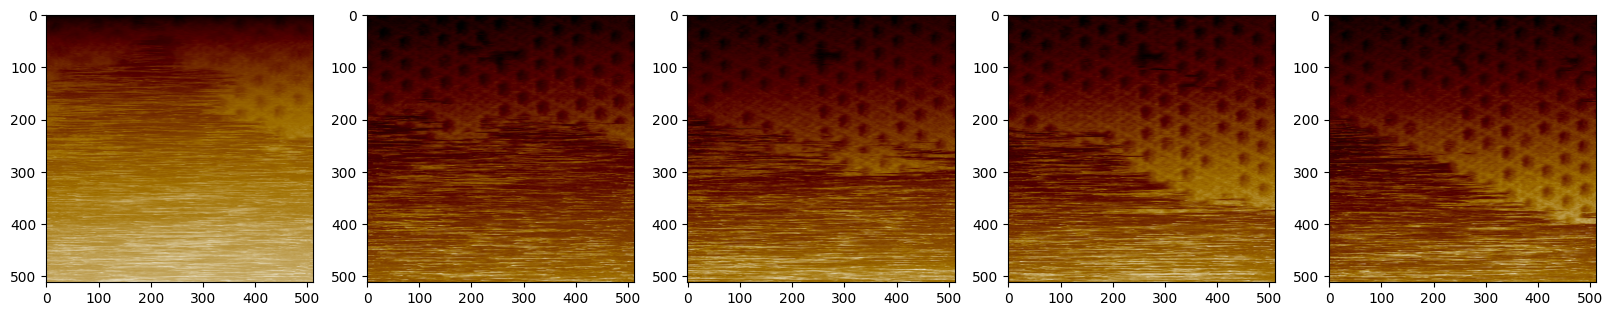

In [3]:
from matplotlib import pyplot as plt

plt.figure(figsize=(20,5))
plt.subplot(1,5,1)
plt.imshow(stack.data[0],cmap=AFM)
plt.subplot(1,5,2)
plt.imshow(stack.data[1],cmap=AFM)
plt.subplot(1,5,3)
plt.imshow(stack.data[2],cmap=AFM)
plt.subplot(1,5,4)
plt.imshow(stack.data[3],cmap=AFM)
plt.subplot(1,5,5)
plt.imshow(stack.data[4],cmap=AFM)

In [6]:
from playnano.processing.pipeline import ProcessingPipeline

if "raw" in stack.processed:
    stack.restore_raw()

pipe = ProcessingPipeline(stack)
pipe.add_filter("select_frames", keep_indices = [0,1,2,3,4])
pipe.add_filter("level_ml_bg", model_path = bg_model_path, lineorder=3)
pipe.add_filter("level_ml_bg", model_path = bg_model_path, lineorder=3)
pipe.add_filter("level_ml_bg", model_path = bg_model_path, lineorder=3)
pipe.add_filter("zero_mean")
pipe.run()

array([[[-0.18887087, -0.16697076, -0.10078669, ...,  0.05585357,
          0.03647439,  0.112801  ],
        [-0.1753621 , -0.04320129, -0.12805068, ...,  0.052527  ,
         -0.25025887, -0.34516566],
        [ 0.99325586,  1.00251811,  0.82150442, ...,  0.78957286,
          0.61149236,  0.4259601 ],
        ...,
        [ 0.37455289,  0.40622243,  0.19889123, ..., -1.12383972,
         -1.28236977, -1.41095606],
        [ 0.42704266,  0.41083337,  0.44597743, ...,  0.23156948,
          0.10258459,  0.04763555],
        [ 0.18803186,  0.22788187,  0.22724634, ..., -1.13652373,
         -1.24258294, -1.21211601]],

       [[ 0.69654586,  0.72348781,  0.6934925 , ...,  0.86692379,
          0.92650381,  1.003474  ],
        [ 1.00533214,  0.97640162,  0.78540873, ...,  1.08109877,
          1.17996539,  1.32705134],
        [ 0.71625245,  0.57711781,  0.73473162, ...,  1.44497326,
          1.3140672 ,  1.31342845],
        ...,
        [ 0.66177544,  0.69886582,  0.82228833, ..., -

In [7]:
print(stack.processed.keys())

dict_keys(['raw', 'step_1_drop_frames', 'step_2_level_ml_bg', 'step_3_level_ml_bg', 'step_4_level_ml_bg', 'step_5_zero_mean'])


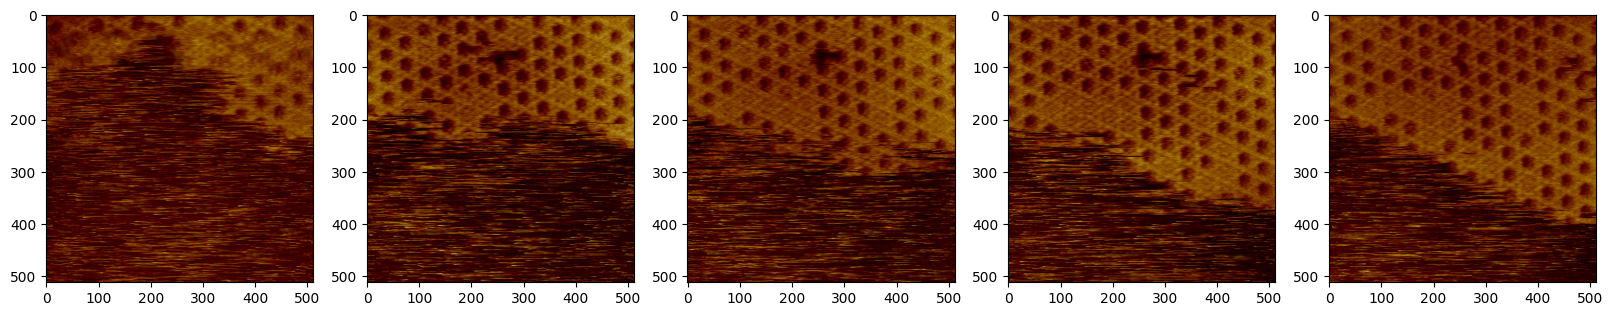

In [8]:
plt.figure(figsize=(20,5))
plt.subplot(1,5,1)
plt.imshow(stack.data[0],cmap=AFM)
plt.subplot(1,5,2)
plt.imshow(stack.data[1],cmap=AFM)
plt.subplot(1,5,3)
plt.imshow(stack.data[2],cmap=AFM)
plt.subplot(1,5,4)
plt.imshow(stack.data[3],cmap=AFM)
plt.subplot(1,5,5)
plt.imshow(stack.data[4],cmap=AFM)

In [ ]:
if "raw" in stack_bg.processed:
    stack_bg.restore_raw()
    
pipe_bg3 = ProcessingPipeline(stack_bg)
pipe_bg3.add_filter("select_frames", keep_indices = [0,1,2,3,4])
pipe_bg3.add_filter("level_ml_bg", model_path = bg_model_path, lineorder=3)
pipe_bg3.add_filter("level_ml_bg", model_path = bg_model_path, lineorder=3)
pipe_bg3.add_filter("level_ml_bg", model_path = bg_model_path, lineorder=3, background=True)
pipe_bg3.run()

In [12]:
bg3 = stack_bg.data
print(bg3)

[[[-3.8214321  -3.81801112 -3.81462855 ... -4.17898465 -4.17814879
   -4.17728455]
  [-3.60905878 -3.60835224 -3.60766222 ... -3.86281089 -3.86150625
   -3.86018268]
  [-3.58674247 -3.58498486 -3.58325267 ... -4.08280713 -4.08276699
   -4.08270807]
  ...
  [-2.57057937 -2.56728446 -2.56402564 ... -2.57098752 -2.56837617
   -2.56573127]
  [-2.73475481 -2.7336084  -2.73247186 ... -3.00300574 -3.00437212
   -3.00573848]
  [-2.45516465 -2.45481041 -2.45446694 ... -2.67233374 -2.67157649
   -2.67080686]]

 [[-4.35024426 -4.3488569  -4.34748259 ... -4.32710308 -4.32641704
   -4.32572066]
  [-4.34478821 -4.34283113 -4.34089159 ... -4.27161895 -4.27063302
   -4.2696333 ]
  [-4.31183016 -4.31012333 -4.30842998 ... -4.2999599  -4.29987367
   -4.29978029]
  ...
  [-2.209935   -2.21578789 -2.22159024 ... -2.49899936 -2.50187382
   -2.50478729]
  [-2.48210664 -2.48397884 -2.48583651 ... -2.47794733 -2.47787695
   -2.4778135 ]
  [-2.37375646 -2.37613161 -2.37848747 ... -2.28672219 -2.28636949
   -2.

In [14]:
if "raw" in stack_bg.processed:
    stack_bg.restore_raw()
    
pipe_bg2 = ProcessingPipeline(stack_bg)
pipe_bg2.add_filter("select_frames", keep_indices = [0,1,2,3,4])
pipe_bg2.add_filter("level_ml_bg", model_path = bg_model_path, lineorder=3)
pipe_bg2.add_filter("level_ml_bg", model_path = bg_model_path, lineorder=3, background=True)
pipe_bg2.run()

bg2 = stack_bg.data

In [15]:
if "raw" in stack_bg.processed:
    stack_bg.restore_raw()
    
pipe_bg1 = ProcessingPipeline(stack_bg)
pipe_bg1.add_filter("select_frames", keep_indices = [0,1,2,3,4])
pipe_bg1.add_filter("level_ml_bg", model_path = bg_model_path, lineorder=3, background=True)
pipe_bg1.run()

bg1=stack_bg.data

In [16]:
combined_bg = bg1 + bg2 + bg3

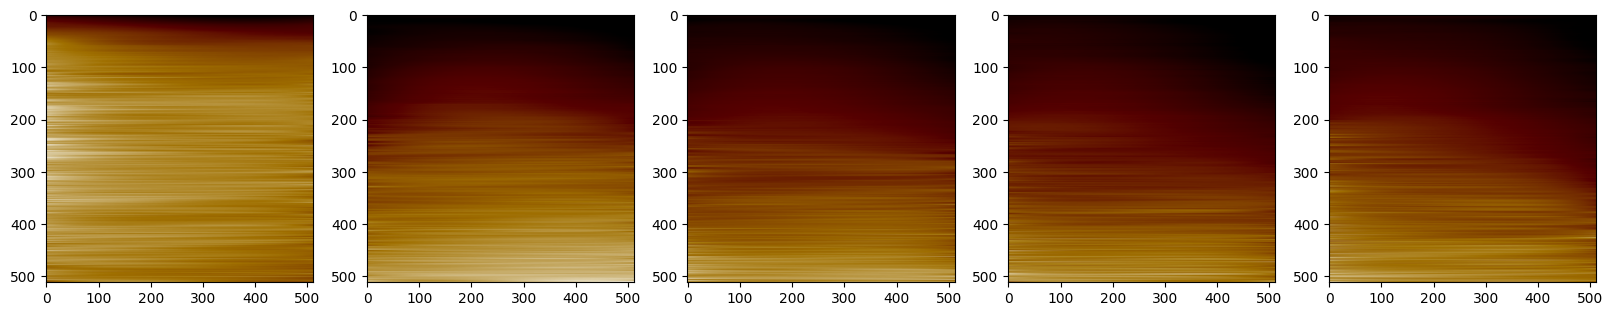

In [17]:
plt.figure(figsize=(20,5))
plt.subplot(1,5,1)
plt.imshow(combined_bg[0],cmap=AFM)
plt.subplot(1,5,2)
plt.imshow(combined_bg[1],cmap=AFM)
plt.subplot(1,5,3)
plt.imshow(combined_bg[2],cmap=AFM)
plt.subplot(1,5,4)
plt.imshow(combined_bg[3],cmap=AFM)
plt.subplot(1,5,5)
plt.imshow(combined_bg[4],cmap=AFM)

dict_keys(['raw', 'step_1_drop_frames', 'step_2_level_ml_bg', 'step_3_level_ml_bg', 'step_4_level_ml_bg', 'step_5_zero_mean'])
{'steps': [{'index': 1, 'name': 'select_frames', 'params': {'keep_indices': [0, 1, 2, 3, 4]}, 'timestamp': '2026-03-09T16:45:21.847084Z', 'step_type': 'stack_edit', 'version': '0.1.0', 'function_module': 'playnano.processing.stack_edit', 'processed_key': 'step_1_drop_frames', 'output_summary': {'stack_edit_function_used': 'select_frames', 'delegated_to': 'drop_frames', 'shape': (5, 512, 512), 'dtype': 'float64'}}, {'index': 2, 'name': 'level_ml_bg', 'params': {'model_path': 'C:\\Users\\pymte\\OneDrive - University of Leeds\\Project 2\\Machine Learning\\afMLevel files\\BGModel.pth', 'lineorder': 3, 'background': True}, 'timestamp': '2026-03-09T16:45:22.135263Z', 'step_type': 'plugin', 'version': '0.1.dev29+g30c737d9e', 'function_module': 'afmlevel.background_model', 'processed_key': 'step_2_level_ml_bg', 'output_summary': {'shape': (5, 512, 512), 'dtype': 'float

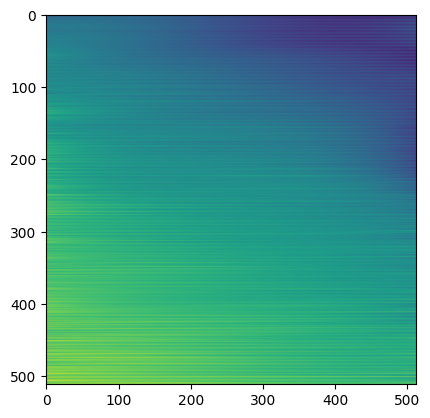

In [24]:
print(stack.processed.keys())
plt.imshow(stack.processed['step_4_level_ml_bg'][0])
print(stack.provenance['processing'])

In [ ]:
#Generate model outputs and display results
if BGrpt == 1 or BGrpt == 2 or BGrpt == 3:
    model_bg, model_levarray = afml.applymodel_bg(imarray, 3, bg_model_path)    
    
if BGrpt == 2 or BGrpt == 3:
    model_bg2, model_levarray2 = afml.applymodel_bg(model_levarray, 3, bg_model_path) #second application of BG model

if BGrpt == 3:
    model_bg3, model_levarray3 = afml.applymodel_bg(model_levarray2, 3, bg_model_path) #third application of BG model

mask = afml.applymodel_mask(imarray, mask_model_path)

if BGrpt == 1:
    BGlev =model_levarray   
if BGrpt == 2:
    BGlev =model_levarray2   
if BGrpt == 3:
    BGlev =model_levarray3   

plt.figure(figsize=(16,4))

plt.subplot(1,3,1)
plt.title("BG model background")
plt.imshow(model_bg, cmap=AFM)

plt.subplot(1,3,2)
plt.title("BG model levelled")
plt.imshow(BGlev, cmap = AFM) 

plt.subplot(1,3,3)
plt.title("Mask model mask")
plt.imshow(mask) 

plt.show()